In [4]:
import re
import requests
import string
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from transformers import GPT2Model, GPT2Tokenizer, BertTokenizer, BertModel
import torch

# Cosine similarity

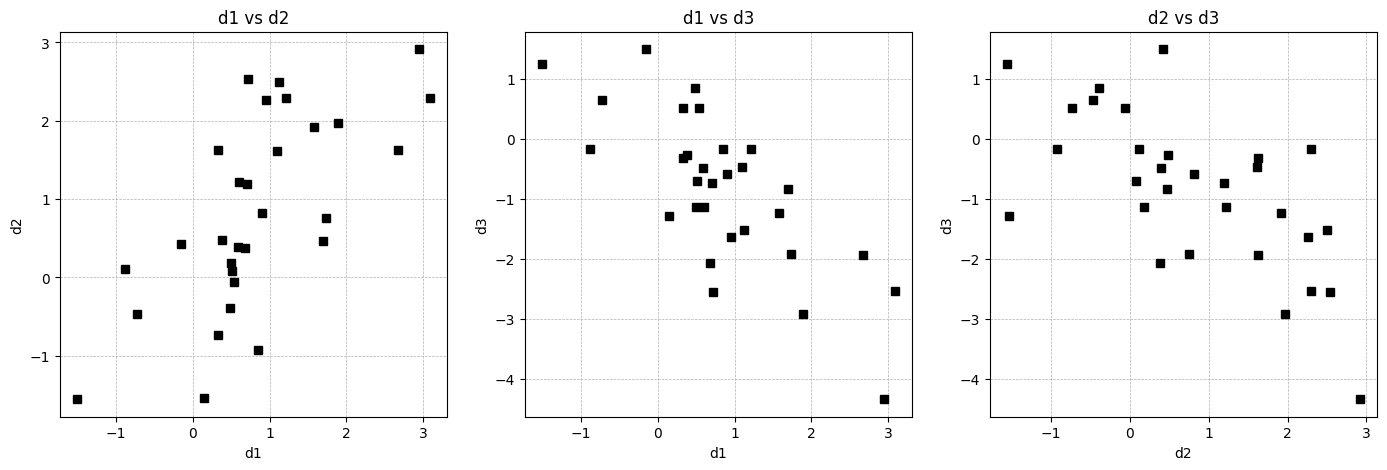

In [5]:
# sample size
from matplotlib.pyplot import xlabel
from pyparsing import line


N = 30

# data vectors
d1 = np.random.randn(N) + 1 # add an offset to appreciate the difference between Pearson and cosine similarity
d2 = d1 + np.random.randn(N)
d3 = -d1 + np.random.randn(N)

# visualize
fig, ax = plt.subplots(1, 3, figsize=(17, 5))
ax[0].plot(d1, d2, "ks")
ax[0].set(xlabel="d1", ylabel="d2", title="d1 vs d2")
ax[0].grid(linewidth=0.5, linestyle="--")
ax[1].plot(d1, d3, "ks")
ax[1].set(xlabel="d1", ylabel="d3", title="d1 vs d3")
ax[1].grid(linewidth=0.5, linestyle="--")
ax[2].plot(d2, d3, "ks")
ax[2].set(xlabel="d2", ylabel="d3", title="d2 vs d3")
ax[2].grid(linewidth=0.5, linestyle="--")
plt.show()

In [6]:
# cosine similarity by manual implementation
def cosine_similarity_manual(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

In [7]:
# we have to reshape the vectors to 2D arrays to use sklearn's cosine_similarity function, since it expects 2D arrays as input
print(d1.shape, d1.reshape(1, -1).shape)

# check our implementation against sklearns implementation
print("Cosine similarity d1 vs d2:", cosine_similarity_manual(d1, d2), cosine_similarity(d1.reshape(1, -1), d2.reshape(1, -1))[0][0])
print("Cosine similarity d1 vs d3:", cosine_similarity_manual(d1, d3), cosine_similarity(d1.reshape(1, -1), d3.reshape(1, -1))[0][0])
print("Cosine similarity d2 vs d3:", cosine_similarity_manual(d2, d3), cosine_similarity(d2.reshape(1, -1), d3.reshape(1, -1))[0][0])

(30,) (1, 30)
Cosine similarity d1 vs d2: 0.787218233245617 0.7872182332456171
Cosine similarity d1 vs d3: -0.8367879073729927 -0.8367879073729925
Cosine similarity d2 vs d3: -0.765398841623767 -0.7653988416237673


In [8]:
# Another way is with the torch library, which has a built-in function for cosine similarity
# but needs the vectors to be torch tensors
torch.cosine_similarity(torch.tensor(d1), torch.tensor(d2), dim=0)

tensor(0.7872, dtype=torch.float64)

In [9]:
# compare mean center data vs pearson correlation
d1_centered = d1 - np.mean(d1)
d2_centered = d2 - np.mean(d2)

pearson_corr_12 = np.corrcoef(d1, d2)[0][1]
pearson_corr_centered_12 = np.corrcoef(d1_centered, d2_centered)[0][1]

print("Pearson correlation d1 vs d2:", pearson_corr_12)
print("Pearson correlation d1_centered vs d2_centered:", pearson_corr_centered_12)

cosine_sim_12 = cosine_similarity_manual(d1, d2)
cosine_sim_centered_12 = cosine_similarity_manual(d1_centered, d2_centered)
print("Cosine similarity d1 vs d2:", cosine_sim_12)
print("Cosine similarity d1_centered vs d2_centered:", cosine_sim_centered_12)

# we can see that the pearson correlation is the same for both centered and non-centered data (since it subtracts the mean), while the cosine similarity is different, 
# since it is affected by the mean of the data. This is because the cosine similarity is based on the angle between the vectors, while 
# the pearson correlation is based on the covariance between the vectors, which is not affected by the mean.

Pearson correlation d1 vs d2: 0.6753443285288716
Pearson correlation d1_centered vs d2_centered: 0.6753443285288716
Cosine similarity d1 vs d2: 0.787218233245617
Cosine similarity d1_centered vs d2_centered: 0.6753443285288716


In [10]:
gpt2 = GPT2Model.from_pretrained("gpt2")
tokenizer_gpt2 = GPT2Tokenizer.from_pretrained("gpt2")
gpt2_wte = gpt2.wte.weight.detach().numpy()

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

In [ ]:
# find tokens with similar embeddings to "king"
word = "Mike"
token = tokenizer_gpt2.encode(word)[0]
embedding = gpt2_wte[token]
token_norm = np.linalg.norm(embedding)

# calculate cosine similarity between the embedding of "Mike" (embedding) and all other embeddings in the vocabulary (gpt2_wte)
all_cosine_similarities = np.dot(gpt2_wte, embedding) / (np.linalg.norm(gpt2_wte, axis=1) * token_norm)

# get the top 10 most similar tokens
top_k = 10
top_k_indices = np.argsort(all_cosine_similarities)[-top_k:][::-1]
similar_tokens = [tokenizer_gpt2.decode([idx]) for idx in top_k_indices]
print(f"Tokens most similar to '{word}': {similar_tokens}")

Tokens most similar to 'Mike': ['Mike', ' Mike', 'Michael', 'Chris', 'Jim', 'Dave', 'Steve', 'Joe', 'Brian', 'Kevin']


In [ ]:
# what if we normalize the embeddings before calculating cosine similarity?
gpt2_wte_normalized = gpt2_wte / np.linalg.norm(gpt2_wte, axis=1, keepdims=True)
embedding_normalized = embedding / token_norm

# as we have normalized, we only need to calculate the dot product to get the cosine similarity, since the norms are now 1
all_cosine_similarities_normalized = np.dot(gpt2_wte_normalized, embedding_normalized) 

top_k_indices_normalized = np.argsort(all_cosine_similarities_normalized)[-top_k:][::-1]
similar_tokens_normalized = [tokenizer_gpt2.decode([idx]) for idx in top_k_indices_normalized]
print(f"Tokens most similar to '{word}' (normalized): {similar_tokens_normalized}")

# we can see that the results are the same, since cosine similarity is invariant to scaling of the vectors, 
# but it is good practice to normalize the embeddings before calculating cosine similarity, since it can help 
# to avoid numerical instability and improve the interpretability of the results.

Tokens most similar to 'Mike' (normalized): ['Mike', ' Mike', 'Michael', 'Chris', 'Jim', 'Dave', 'Steve', 'Joe', 'Brian', 'Kevin']
